   user_id      group  converted
0        1    control          0
1        2  treatment          0
2        3  treatment          0
3        4    control          0
4        5  treatment          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    2000 non-null   int64 
 1   group      2000 non-null   object
 2   converted  2000 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 47.0+ KB
None
           user_id    converted
count  2000.000000  2000.000000
mean   1000.500000     0.139000
std     577.494589     0.346033
min       1.000000     0.000000
25%     500.750000     0.000000
50%    1000.500000     0.000000
75%    1500.250000     0.000000
max    2000.000000     1.000000
converted
0    1722
1     278
Name: count, dtype: int64


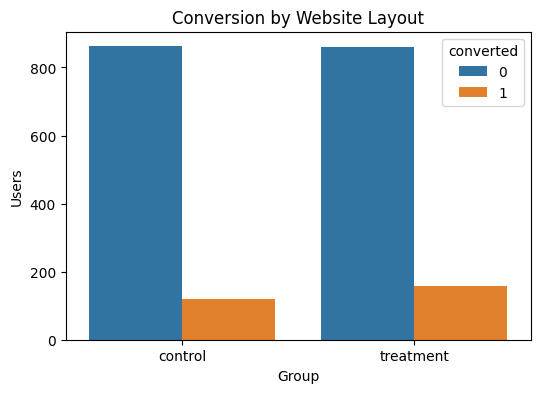

group
control      0.121305
treatment    0.156035
Name: converted, dtype: float64


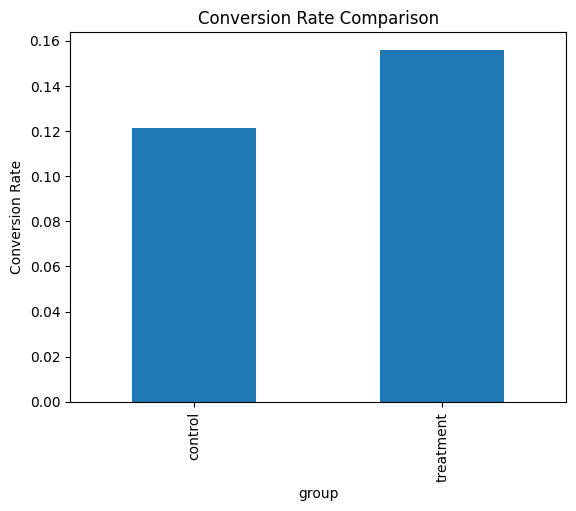

T-statistic: 2.2461538876685823
P-value: 0.024803008088614333
Reject Null Hypothesis
New website layout significantly improves conversion rate
(np.float64(0.0044067632009425275), np.float64(0.06505431224729433))
Control Conversion Rate: 0.12130479102956167
Treatment Conversion Rate: 0.1560353287536801
Conversion Improvement: 3.473053772411842 %

BUSINESS STORY

Objective:
Evaluate whether the new website layout improves conversion rates.

Key Findings:
Control Conversion Rate: 0.12130479102956167
Treatment Conversion Rate: 0.1560353287536801

Improvement:
3.47% increase in conversion.

Statistical Result:
P-value = 0.024803008088614333

Conclusion:



In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms

data = pd.read_csv('/content/ab_testing_dataset.csv')

print(data.head())
print(data.info())
print(data.describe())

print(data['converted'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='group', hue='converted', data=data)
plt.title("Conversion by Website Layout")
plt.xlabel("Group")
plt.ylabel("Users")
plt.show()

conversion_rate = data.groupby('group')['converted'].mean()
print(conversion_rate)

conversion_rate.plot(kind='bar')
plt.title("Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.show()

control = data[data['group'] == 'control']['converted']
treatment = data[data['group'] == 'treatment']['converted']

t_stat, p_value = stats.ttest_ind(treatment, control)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("New website layout significantly improves conversion rate")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant improvement in conversion rate")

cm = sms.CompareMeans(
    sms.DescrStatsW(treatment),
    sms.DescrStatsW(control)
)

print(cm.tconfint_diff())

control_rate = control.mean()
treatment_rate = treatment.mean()

print("Control Conversion Rate:", control_rate)
print("Treatment Conversion Rate:", treatment_rate)

improvement = (treatment_rate - control_rate) * 100
print("Conversion Improvement:", improvement,"%")

summary = f"""
BUSINESS STORY

Objective:
Evaluate whether the new website layout improves conversion rates.

Key Findings:
Control Conversion Rate: {control_rate}
Treatment Conversion Rate: {treatment_rate}

Improvement:
{improvement:.2f}% increase in conversion.

Statistical Result:
P-value = {p_value}

Conclusion:
"""

print(summary)

data.to_csv("analysis_results.csv", index=False)